## Caso de Estudio 

Una empresa internacional de seguros médicos, en proceso de expansión en América Latina, ha identificado la necesidad de mejorar sus procesos de análisis de clientes. Actualmente, la empresa enfrenta dificultades para anticipar el comportamiento financiero de sus asegurados, lo que impacta directamente en la definición de primas, estrategias de cobertura y sostenibilidad del negocio. Durante los 
últimos años, la compañía ha recolectado información detallada de sus clientes, incluyendo características demográficas, hábitos de vida y algunos indicadores médicos relevantes. Entre estos datos se encuentran variables como la edad, sexo, el índice de masa corporal (BMI), el número de hijos, el hábito de fumar, y la región geográfica donde residen. Adicionalmente, la empresa cuenta con el registro histórico del costo anual en servicios médicos asociado a cada cliente. El equipo directivo ha solicitado al área de inteligencia artificial desarrollar un modelo de Machine Learning que permita aprovechar estos datos para mejorar la toma de decisiones.

## Regresión

Debido a que necesitan anticipar el comportamiento financiero de sus asegurados, es decir quieren predecir un valor, cual seria el gasto anual de cada asociado

1) Carga y exploracion de datos

In [56]:
# Importacion de librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargamos el dataset
data = ("insurance.csv", '.csv', False)
df = pd.read_csv(data[0])

In [93]:
# visualizamos las primeras filas del dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [58]:
# Informacion general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [59]:
# Estadisticas basicas del dataset
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


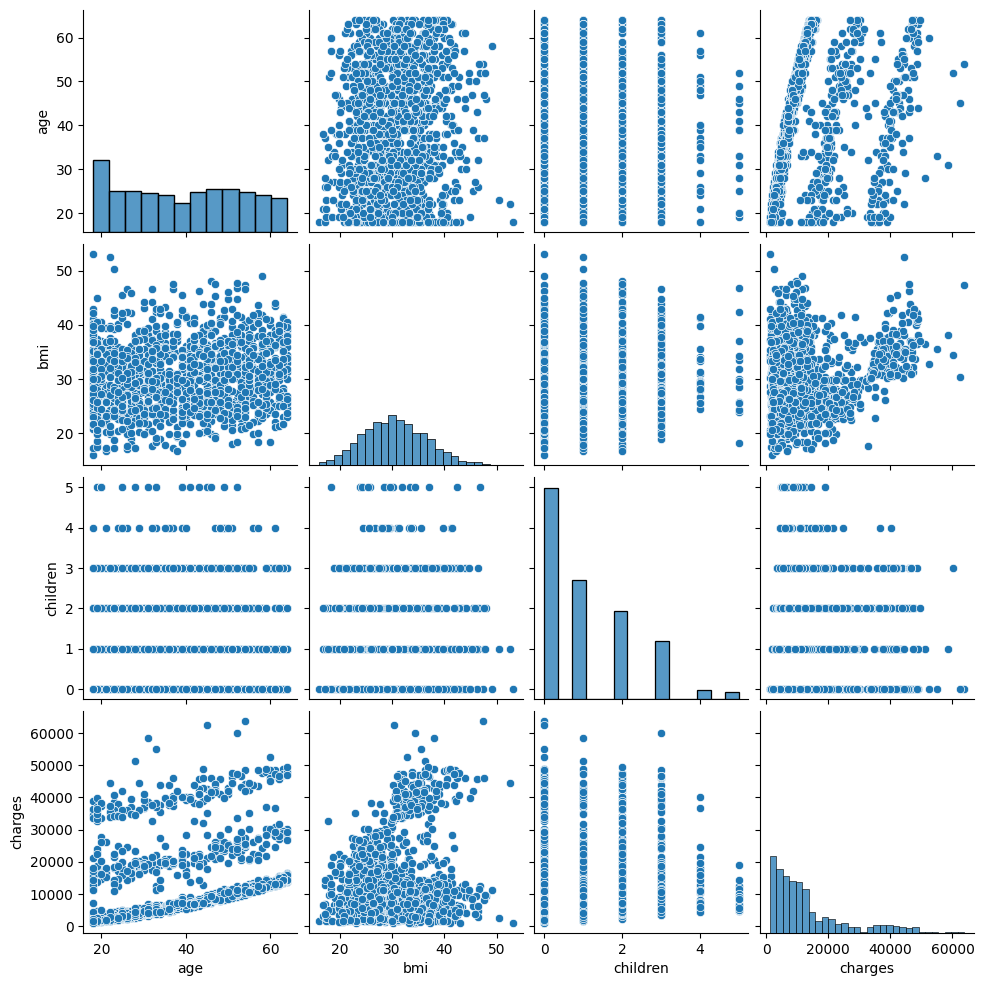

In [60]:
# visualizamos la relacion entre las variables
sns.pairplot(df)
plt.show()

2) Preparar los datos

In [61]:
# Separar variables predictoras y variable objetivo

# Variables predictoras, todas excepto la variable objetivo "charges"
X = df.drop("charges", axis=1)

# Variable objetivo
y = df["charges"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (1338, 6)
Dimensiones de y: (1338,)


In [62]:
# Visualizamos las primeras filas de las variables predictoras
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [63]:
# Visualizamos las primeras filas de la variable objetivo
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [64]:
# Identificamos las variables numericas y categoricas

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)   

Variables numéricas: ['age', 'bmi', 'children']
Variables categóricas: ['sex', 'smoker', 'region']


C:\Users\soporte.sistemas\AppData\Local\Temp\ipykernel_25072\115652262.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [65]:
# Creamos las transformaciones para las variables numericas y categoricas

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [66]:
# Aplicamos las transformaciones a las variables predictoras

X_transformed = preprocessor.fit_transform(X)

print("Transformación completada")
print("Tipo de resultado:", type(X_transformed))
print("Dimensiones transformadas:", X_transformed.shape)

Transformación completada
Tipo de resultado: <class 'numpy.ndarray'>
Dimensiones transformadas: (1338, 11)


In [70]:
# Convertimos el resultado a un DataFrame para facilitar su uso posterior

encoded_cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

X_prepared = pd.DataFrame(X_transformed, columns=all_feature_names)

X_prepared.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.509965,0.509621,-0.078767,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.797954,0.383307,1.580926,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.441948,-1.305531,-0.908614,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.513149,-0.292556,-0.908614,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


3) Entrenamiento de modelo

In [78]:
# Escogemos la variable objetivo y las variables predictoras
from sklearn.linear_model import LinearRegression

# Variables predictoras, todas excepto la variable objetivo "charges"
X = X_prepared

# Variable objetivo
y = df["charges"]



In [79]:
# Dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# X: variables predictoras
# y: variable objetivo

# Se divide el dataset en:
# - 80% para entrenamiento (train)
# - 20% para prueba (test)
# random_state garantiza que la división sea reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=2529
)

In [80]:
# Importar el modelo de árbol de decisión para regresión y la función para visualizar el árbol
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Crear el modelo de árbol de decisión
# max_depth=6 especifica la profundidad del árbol
# random_state=2529 asegura que los resultados sean reproducibles
dtr = DecisionTreeRegressor(max_depth=6, random_state=2529)

In [81]:
# Validar el modelo utilizando validación cruzada (cross-validation)
from sklearn.model_selection import cross_validate

# Se evalúa el modelo dtr utilizando únicamente los datos de entrenamiento
# cv=5 indica que se realizará una validación cruzada con 5 particiones (folds)
# El modelo se entrena y valida 5 veces con diferentes subconjuntos de los datos
# Esto permite obtener una estimación más robusta del desempeño del modelo

cross_validate(dtr, X_train, y_train, cv=5)

{'fit_time': array([0.0092845 , 0.00677824, 0.00582147, 0.00722551, 0.00759768]),
 'score_time': array([0.00434661, 0.00252819, 0.00312614, 0.00227451, 0.00251818]),
 'test_score': array([0.81452727, 0.75140548, 0.85420457, 0.81079305, 0.77797602])}

In [82]:
# Mostrar los hiperparámetros actuales del modelo de árbol de decisión
# Esto permite conocer la configuración inicial del modelo antes de optimizarlo
dtr.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 6,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 2529,
 'splitter': 'best'}

In [83]:
# Definir las combinaciones de hiperparámetros que se desean evaluar
# model__ indica que estos parámetros pertenecen al modelo dentro del Pipeline

params = {
    'model__max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10],   # Profundidad máxima del árbol
    'model__criterion': ['squared_error', 'absolute_error'],  # Función de error para dividir nodos
    'model__random_state': [2529]   # Semilla para asegurar reproducibilidad
}

In [84]:
# Importar la clase Pipeline
# Pipeline permite organizar el flujo de trabajo del modelo dentro de una sola estructura
from sklearn.pipeline import Pipeline

In [85]:
# Definir un pipeline que contiene el modelo de árbol de decisión
# En este caso solo se incluye un paso llamado 'model'
pipe = Pipeline([('model', dtr)])

In [86]:
# Importar GridSearchCV
# Esta herramienta prueba múltiples combinaciones de hiperparámetros
# y selecciona la mejor utilizando validación cruzada
from sklearn.model_selection import GridSearchCV

# Crear el objeto GridSearchCV
# cv=5 indica que se usará validación cruzada con 5 particiones
grid = GridSearchCV(pipe, params, cv=5)

In [87]:
# Mostrar la configuración del Grid Search
# Esto permite verificar el estimador, el pipeline y la grilla de parámetros
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=2529))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': [2, 3, ...], 'model__random_state': [2529]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [88]:
# Entrenar GridSearchCV con los datos de entrenamiento
# El algoritmo probará todas las combinaciones de hiperparámetros definidas
# y evaluará cada una utilizando validación cruzada
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=2529))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': [2, 3, ...], 'model__random_state': [2529]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [89]:
# Mostrar la mejor combinación de hiperparámetros encontrada
# según el desempeño obtenido durante la validación cruzada
grid.best_params_

{'model__criterion': 'absolute_error',
 'model__max_depth': 4,
 'model__random_state': 2529}

Modelo óptimo entrenado
R² en entrenamiento: 0.8565

Evaluación en conjunto de prueba
--------------------------------
MAE  (Error absoluto medio): 2344.1312
MAPE (Error porcentual medio): 0.2049
R²   (Coeficiente de determinación): 0.8405
MSE  (Error cuadrático medio): 24498899.5658


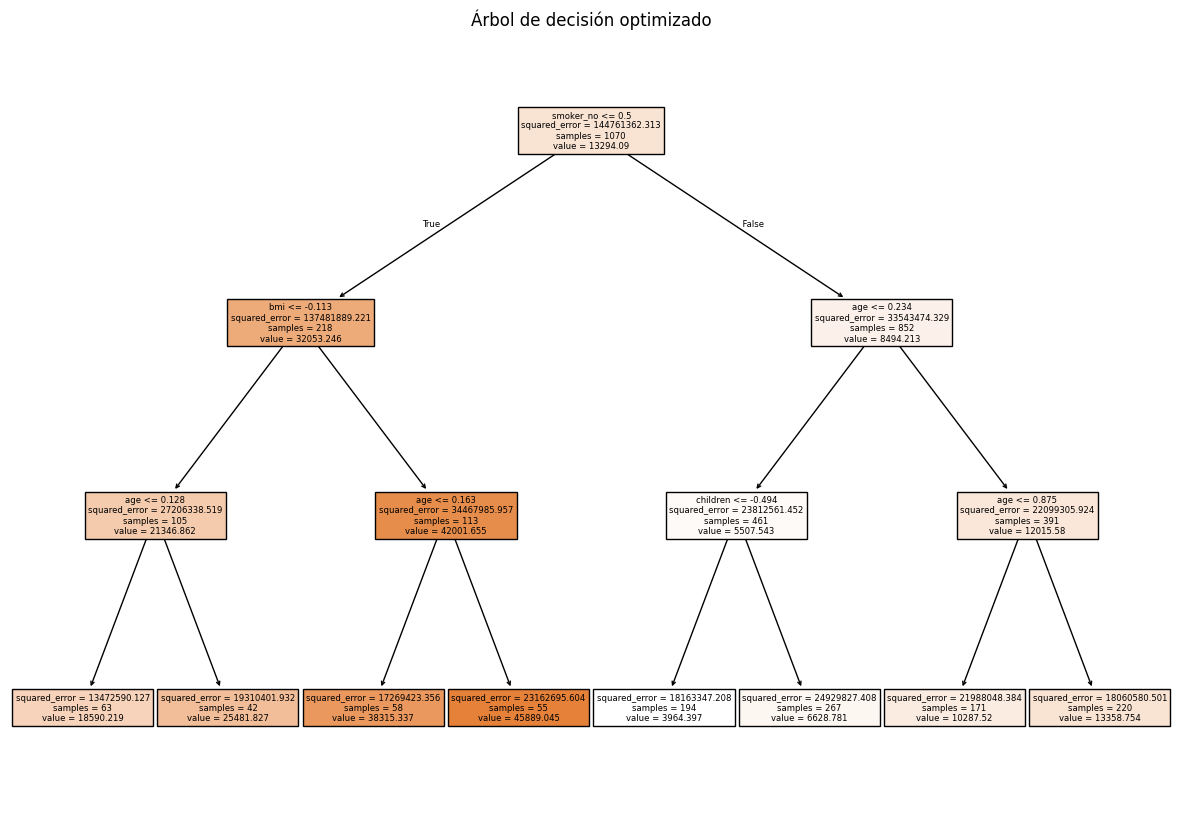

In [92]:
# ================================
# 1. Seleccionar mejor modelo
# ================================
best = grid.best_estimator_

# ================================
# 2. Entrenar mejor modelo
# ================================
best.fit(X_train, y_train)

print("Modelo óptimo entrenado")

# ================================
# 3. Evaluación en entrenamiento
# ================================
train_score = best.score(X_train, y_train)
print(f"R² en entrenamiento: {train_score:.4f}")

# ================================
# 4. Predicciones en test
# ================================
y_pred = best.predict(X_test)

# ================================
# 5. Métricas de evaluación
# ================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nEvaluación en conjunto de prueba")
print("--------------------------------")
print(f"MAE  (Error absoluto medio): {mae:.4f}")
print(f"MAPE (Error porcentual medio): {mape:.4f}")
print(f"R²   (Coeficiente de determinación): {r2:.4f}")
print(f"MSE  (Error cuadrático medio): {mse:.4f}")

# ================================
# 6. Visualización del árbol
# ================================
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, DecisionTreeRegressor

# Crear modelo final (mismos hiperparámetros óptimos)
final = DecisionTreeRegressor(max_depth=3, random_state=2529)
final.fit(X_train, y_train)

# Graficar árbol
fig, ax = plt.subplots(figsize=(15, 10))
plot_tree(final, feature_names=X.columns, filled=True)

plt.title("Árbol de decisión optimizado")
plt.show()

In [91]:
# Mostrar la mejor combinación de hiperparámetros encontrada
# según el desempeño obtenido durante la validación cruzada
grid.best_params_

{'model__criterion': 'absolute_error',
 'model__max_depth': 4,
 'model__random_state': 2529}

## Conclusion

Podemos concluir que el modelo que la mejor optimizacion del modelo con los datos, suministrados tenemos que esta cerca de un 86% de efectividad pára predecir el gasto anual de cada asociado